In [1]:
!pip install rdkit

In [ ]:
#TUNING THE PARAMETERS
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import AllChem

from itertools import product

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
y = data["H"].values

# ===============================
# EXTRAPOLATION SPLIT
# ===============================
train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

smiles_train_full = smiles[train_mask]
y_train_full = y[train_mask]

smiles_test = smiles[test_mask]
y_test = y[test_mask]

print("Training molecules:", len(smiles_train_full))
print("Test molecules:", len(smiles_test))

# ===============================
# VALIDATION SPLIT FROM TRAINING
# ===============================
smiles_train, smiles_val, y_train, y_val = train_test_split(
    smiles_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42
)

print("Train molecules:", len(smiles_train))
print("Validation molecules:", len(smiles_val))
print("Test molecules:", len(smiles_test))

# ===============================
# MORGAN FP FUNCTION
# ===============================
def smiles_to_fp(smiles_string, radius, nBits):

    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return np.zeros((nBits,), dtype=np.uint8)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=nBits
    )

    return np.array(fp, dtype=np.uint8)
    
print("STARTED")

# ===============================
# ONE TO THREE HIDDEN LAYER ANN
# ===============================
def create_model(input_dim,
                 architecture,
                 lr=0.001,
                 activation="relu"):

    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    # Hidden layers with different neurons
    for neurons in architecture:
        model.add(
            tf.keras.layers.Dense(neurons, activation=activation)
        )

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# ===============================
# TUNING PARAMETERS
# ===============================
# ===============================
# TUNING PARAMETERS
# ===============================
radius_list = [2, 3]
nBits_list = [1024, 2048, 4096]

layers_list = [1, 2, 3]

neurons_list = [
    32,
    64,
    128,
    256,
    512,
    1024,
    2048
]

lr_list = [0.001]

results = []

best_val_r2 = -999
best_result = None

# Count total architectures
total_architectures = sum(
    len(neurons_list) ** n
    for n in layers_list
)

total_runs = (
    len(radius_list)
    * len(nBits_list)
    * len(lr_list)
    * total_architectures
)

run = 1

# ===============================
# MORGAN FP LOOP
# ===============================
for radius in radius_list:

    for nBits in nBits_list:

        print("\n====================================")
        print(f"Generating Morgan FP: radius={radius}, nBits={nBits}")
        print("====================================")

        # ---------------------------
        # Generate fingerprints ONCE
        # ---------------------------
        X_train = np.array([
            smiles_to_fp(sm, radius, nBits)
            for sm in smiles_train
        ])

        X_val = np.array([
            smiles_to_fp(sm, radius, nBits)
            for sm in smiles_val
        ])

        X_test = np.array([
            smiles_to_fp(sm, radius, nBits)
            for sm in smiles_test
        ])

        # ---------------------------
        # Scale X
        # ---------------------------
        x_scaler = StandardScaler()

        X_train_scaled = x_scaler.fit_transform(X_train)
        X_val_scaled = x_scaler.transform(X_val)
        X_test_scaled = x_scaler.transform(X_test)

        # ---------------------------
        # Scale y
        # ---------------------------
        y_scaler = StandardScaler()

        y_train_scaled = y_scaler.fit_transform(
            y_train.reshape(-1, 1)
        ).flatten()

        y_val_scaled = y_scaler.transform(
            y_val.reshape(-1, 1)
        ).flatten()

        # ===========================
        # ANN TUNING LOOP
        # ===========================
            
        for n_layers in layers_list:

            # Generate architectures with exactly n_layers
            architectures = [
                list(combo)
                for combo in product(
                    neurons_list,
                    repeat=n_layers
                )
            ]

            for architecture in architectures:

                for lr in lr_list:

                    print(
                        f"\n[{run}/{total_runs}] "
                        f"radius={radius}, "
                        f"nBits={nBits}, "
                        f"layers={n_layers}, "
                        f"architecture={architecture}, "
                        f"lr={lr}"
                    )

                    # -----------------------
                    # Build model
                    # -----------------------
                    model = create_model(
                        input_dim=nBits,
                        architecture=architecture,
                        lr=lr
                    )

                    # -----------------------
                    # Train
                    # -----------------------
                    history = model.fit(
                        X_train_scaled,
                        y_train_scaled,
                        validation_data=(
                            X_val_scaled,
                            y_val_scaled
                        ),
                        epochs=200,
                        batch_size=100,
                        callbacks=[early_stop],
                        verbose=0
                    )

                    # -----------------------
                    # Predictions
                    # -----------------------
                    y_train_pred = y_scaler.inverse_transform(
                        model.predict(
                            X_train_scaled,
                            verbose=0
                        )
                    ).flatten()

                    y_val_pred = y_scaler.inverse_transform(
                        model.predict(
                            X_val_scaled,
                            verbose=0
                        )
                    ).flatten()

                    y_test_pred = y_scaler.inverse_transform(
                        model.predict(
                            X_test_scaled,
                            verbose=0
                        )
                    ).flatten()

                    # -----------------------
                    # R² Scores
                    # -----------------------
                    r2_train = r2_score(
                        y_train,
                        y_train_pred
                    )

                    r2_val = r2_score(
                        y_val,
                        y_val_pred
                    )

                    r2_test = r2_score(
                        y_test,
                        y_test_pred
                    )

                    print(
                        f"Train R²={r2_train:.4f} | "
                        f"Val R²={r2_val:.4f} | "
                        f"Test R²={r2_test:.4f}"
                    )

                    result = {
                        "radius": radius,
                        "nBits": nBits,
                        "layers": n_layers,
                        "architecture": architecture,
                        "lr": lr,
                        "r2_train": r2_train,
                        "r2_val": r2_val,
                        "r2_test": r2_test
                    }

                    results.append(result)

                    # -----------------------
                    # Save Best Model
                    # -----------------------
                    if r2_val > best_val_r2:

                        best_val_r2 = r2_val
                        best_result = result

                    run += 1
# ===============================
# RESULTS DATAFRAME
# ===============================
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="r2_val",
    ascending=False
)

print("\n====================================")
print("TOP 10 RESULTS")
print("====================================")

print(results_df.head(10))

# Save results
results_df.to_csv(
    "Morgan_ANN_Tuning_Results.csv",
    index=False
)

# ===============================
# BEST RESULT
# ===============================
print("\n====================================")
print("BEST RESULT")
print("====================================")

print("Radius :", best_result["radius"])
print("nBits  :", best_result["nBits"])
print("Layers :", best_result["layers"])
print("architecture:", best_result["architecture"])
print("LR     :", best_result["lr"])

print("\nTrain R² :", best_result["r2_train"])
print("Val R²   :", best_result["r2_val"])
print("Test R²  :", best_result["r2_test"])


Training molecules: 109016
Test molecules: 24869
Train molecules: 87212
Validation molecules: 21804
Test molecules: 24869
STARTED

Generating Morgan FP: radius=2, nBits=1024

[1/2394] radius=2, nBits=1024, layers=1, architecture=[32], lr=0.001
Train R²=0.7842 | Val R²=0.6371 | Test R²=0.6128

[2/2394] radius=2, nBits=1024, layers=1, architecture=[64], lr=0.001
Train R²=0.7963 | Val R²=0.6354 | Test R²=0.6266

[3/2394] radius=2, nBits=1024, layers=1, architecture=[128], lr=0.001
Train R²=0.8489 | Val R²=0.6340 | Test R²=0.6378

[4/2394] radius=2, nBits=1024, layers=1, architecture=[256], lr=0.001
Train R²=0.8685 | Val R²=0.6327 | Test R²=0.6637

[5/2394] radius=2, nBits=1024, layers=1, architecture=[512], lr=0.001
Train R²=0.9819 | Val R²=0.6769 | Test R²=0.6894

[6/2394] radius=2, nBits=1024, layers=1, architecture=[1024], lr=0.001
Train R²=0.9718 | Val R²=0.6777 | Test R²=0.6929

[7/2394] radius=2, nBits=1024, layers=1, architecture=[2048], lr=0.001
Train R²=0.9604 | Val R²=0.6784 | T

Train R²=0.7830 | Val R²=0.6241 | Test R²=0.5799

[65/2394] radius=2, nBits=1024, layers=3, architecture=[32, 64, 64], lr=0.001
Train R²=0.7651 | Val R²=0.6296 | Test R²=0.5760

[66/2394] radius=2, nBits=1024, layers=3, architecture=[32, 64, 128], lr=0.001
Train R²=0.7460 | Val R²=0.6285 | Test R²=0.5615

[67/2394] radius=2, nBits=1024, layers=3, architecture=[32, 64, 256], lr=0.001
Train R²=0.7751 | Val R²=0.6339 | Test R²=0.5747

[68/2394] radius=2, nBits=1024, layers=3, architecture=[32, 64, 512], lr=0.001
Train R²=0.7751 | Val R²=0.6398 | Test R²=0.5741

[69/2394] radius=2, nBits=1024, layers=3, architecture=[32, 64, 1024], lr=0.001
Train R²=0.8140 | Val R²=0.6391 | Test R²=0.5768

[70/2394] radius=2, nBits=1024, layers=3, architecture=[32, 64, 2048], lr=0.001
Train R²=0.7899 | Val R²=0.6365 | Test R²=0.5932

[71/2394] radius=2, nBits=1024, layers=3, architecture=[32, 128, 32], lr=0.001
Train R²=0.7673 | Val R²=0.6361 | Test R²=0.5761

[72/2394] radius=2, nBits=1024, layers=3, arch

Train R²=0.7975 | Val R²=0.6375 | Test R²=0.5985

[128/2394] radius=2, nBits=1024, layers=3, architecture=[64, 256, 64], lr=0.001
Train R²=0.7919 | Val R²=0.6368 | Test R²=0.5743

[129/2394] radius=2, nBits=1024, layers=3, architecture=[64, 256, 128], lr=0.001
Train R²=0.8005 | Val R²=0.6384 | Test R²=0.5886

[130/2394] radius=2, nBits=1024, layers=3, architecture=[64, 256, 256], lr=0.001
Train R²=0.8545 | Val R²=0.6443 | Test R²=0.5940

[131/2394] radius=2, nBits=1024, layers=3, architecture=[64, 256, 512], lr=0.001
Train R²=0.7961 | Val R²=0.6420 | Test R²=0.5683

[132/2394] radius=2, nBits=1024, layers=3, architecture=[64, 256, 1024], lr=0.001
Train R²=0.8076 | Val R²=0.6414 | Test R²=0.5815

[133/2394] radius=2, nBits=1024, layers=3, architecture=[64, 256, 2048], lr=0.001
Train R²=0.8400 | Val R²=0.6355 | Test R²=0.6119

[134/2394] radius=2, nBits=1024, layers=3, architecture=[64, 512, 32], lr=0.001
Train R²=0.8531 | Val R²=0.6472 | Test R²=0.6004

[135/2394] radius=2, nBits=1024, 

Train R²=0.9956 | Val R²=0.7184 | Test R²=0.5975

[191/2394] radius=2, nBits=1024, layers=3, architecture=[128, 1024, 64], lr=0.001
Train R²=0.9937 | Val R²=0.7184 | Test R²=0.6002

[192/2394] radius=2, nBits=1024, layers=3, architecture=[128, 1024, 128], lr=0.001
Train R²=0.9938 | Val R²=0.7183 | Test R²=0.5793

[193/2394] radius=2, nBits=1024, layers=3, architecture=[128, 1024, 256], lr=0.001
Train R²=0.9949 | Val R²=0.7188 | Test R²=0.5727

[194/2394] radius=2, nBits=1024, layers=3, architecture=[128, 1024, 512], lr=0.001
Train R²=0.9926 | Val R²=0.7143 | Test R²=0.5820

[195/2394] radius=2, nBits=1024, layers=3, architecture=[128, 1024, 1024], lr=0.001
Train R²=0.9947 | Val R²=0.7125 | Test R²=0.5778

[196/2394] radius=2, nBits=1024, layers=3, architecture=[128, 1024, 2048], lr=0.001
Train R²=0.9944 | Val R²=0.7096 | Test R²=0.5714

[197/2394] radius=2, nBits=1024, layers=3, architecture=[128, 2048, 32], lr=0.001
Train R²=0.9947 | Val R²=0.7135 | Test R²=0.5840

[198/2394] radius=2

Train R²=0.9963 | Val R²=0.7431 | Test R²=0.5733

[253/2394] radius=2, nBits=1024, layers=3, architecture=[512, 32, 32], lr=0.001
Train R²=0.9947 | Val R²=0.7375 | Test R²=0.5951

[254/2394] radius=2, nBits=1024, layers=3, architecture=[512, 32, 64], lr=0.001
Train R²=0.9957 | Val R²=0.7379 | Test R²=0.5960

[255/2394] radius=2, nBits=1024, layers=3, architecture=[512, 32, 128], lr=0.001
Train R²=0.9880 | Val R²=0.7235 | Test R²=0.5842

[256/2394] radius=2, nBits=1024, layers=3, architecture=[512, 32, 256], lr=0.001
Train R²=0.9914 | Val R²=0.7269 | Test R²=0.5923

[257/2394] radius=2, nBits=1024, layers=3, architecture=[512, 32, 512], lr=0.001
Train R²=0.9859 | Val R²=0.7196 | Test R²=0.5518

[258/2394] radius=2, nBits=1024, layers=3, architecture=[512, 32, 1024], lr=0.001
Train R²=0.9966 | Val R²=0.7335 | Test R²=0.5877

[259/2394] radius=2, nBits=1024, layers=3, architecture=[512, 32, 2048], lr=0.001
Train R²=0.9899 | Val R²=0.7300 | Test R²=0.5969

[260/2394] radius=2, nBits=1024, 

Train R²=0.9941 | Val R²=0.7429 | Test R²=0.6039

[316/2394] radius=2, nBits=1024, layers=3, architecture=[1024, 128, 32], lr=0.001
Train R²=0.9934 | Val R²=0.7508 | Test R²=0.5832

[317/2394] radius=2, nBits=1024, layers=3, architecture=[1024, 128, 64], lr=0.001
Train R²=0.9954 | Val R²=0.7562 | Test R²=0.5988

[318/2394] radius=2, nBits=1024, layers=3, architecture=[1024, 128, 128], lr=0.001
Train R²=0.9937 | Val R²=0.7531 | Test R²=0.5908

[319/2394] radius=2, nBits=1024, layers=3, architecture=[1024, 128, 256], lr=0.001
Train R²=0.9889 | Val R²=0.7465 | Test R²=0.5713

[320/2394] radius=2, nBits=1024, layers=3, architecture=[1024, 128, 512], lr=0.001
Train R²=0.9895 | Val R²=0.7420 | Test R²=0.5978

[321/2394] radius=2, nBits=1024, layers=3, architecture=[1024, 128, 1024], lr=0.001
Train R²=0.9950 | Val R²=0.7472 | Test R²=0.5830

[322/2394] radius=2, nBits=1024, layers=3, architecture=[1024, 128, 2048], lr=0.001
Train R²=0.9927 | Val R²=0.7420 | Test R²=0.6012

[323/2394] radius=2

Train R²=0.9905 | Val R²=0.7559 | Test R²=0.5714

[378/2394] radius=2, nBits=1024, layers=3, architecture=[2048, 256, 2048], lr=0.001
Train R²=0.9949 | Val R²=0.7532 | Test R²=0.5940

[379/2394] radius=2, nBits=1024, layers=3, architecture=[2048, 512, 32], lr=0.001
Train R²=0.9941 | Val R²=0.7551 | Test R²=0.5516

[380/2394] radius=2, nBits=1024, layers=3, architecture=[2048, 512, 64], lr=0.001
Train R²=0.9932 | Val R²=0.7612 | Test R²=0.5771

[381/2394] radius=2, nBits=1024, layers=3, architecture=[2048, 512, 128], lr=0.001
Train R²=0.9972 | Val R²=0.7821 | Test R²=0.5731

[382/2394] radius=2, nBits=1024, layers=3, architecture=[2048, 512, 256], lr=0.001
Train R²=0.9939 | Val R²=0.7704 | Test R²=0.5997

[383/2394] radius=2, nBits=1024, layers=3, architecture=[2048, 512, 512], lr=0.001
Train R²=0.9937 | Val R²=0.7673 | Test R²=0.5950

[384/2394] radius=2, nBits=1024, layers=3, architecture=[2048, 512, 1024], lr=0.001
Train R²=0.9921 | Val R²=0.7528 | Test R²=0.5946

[385/2394] radius=2

Started
(133885, 4096)
int64
success
Fixed Test Samples: 24869

Training Fraction = 15%
Training Samples = 16352
Epoch 1/200
131/131 [==============================] - 2s 4ms/step - loss: 1.9551 - mae: 1.0915 - val_loss: 0.9567 - val_mae: 0.7748
Epoch 2/200
131/131 [==============================] - 0s 4ms/step - loss: 0.6273 - mae: 0.6117 - val_loss: 0.5969 - val_mae: 0.6006
Epoch 3/200
131/131 [==============================] - 0s 4ms/step - loss: 0.2694 - mae: 0.3997 - val_loss: 0.5385 - val_mae: 0.5700
Epoch 4/200
131/131 [==============================] - 0s 4ms/step - loss: 0.1753 - mae: 0.3201 - val_loss: 0.5430 - val_mae: 0.5724
Epoch 5/200
131/131 [==============================] - 0s 4ms/step - loss: 0.1341 - mae: 0.2792 - val_loss: 0.5391 - val_mae: 0.5676
Epoch 6/200
131/131 [==============================] - 0s 4ms/step - loss: 0.1161 - mae: 0.2579 - val_loss: 0.5379 - val_mae: 0.5721
Epoch 7/200
131/131 [==============================] - 0s 4ms/step - loss: 0.1033 - mae: 

131/131 [==============================] - 0s 4ms/step - loss: 0.0418 - mae: 0.1245 - val_loss: 0.5306 - val_mae: 0.5627
Epoch 123/200
131/131 [==============================] - 0s 3ms/step - loss: 0.0427 - mae: 0.1261 - val_loss: 0.5257 - val_mae: 0.5590
Epoch 124/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0418 - mae: 0.1240 - val_loss: 0.5384 - val_mae: 0.5644
Epoch 125/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0413 - mae: 0.1216 - val_loss: 0.5425 - val_mae: 0.5686
Epoch 126/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0412 - mae: 0.1220 - val_loss: 0.5363 - val_mae: 0.5649
Epoch 127/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0415 - mae: 0.1232 - val_loss: 0.5354 - val_mae: 0.5657
Epoch 128/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0421 - mae: 0.1239 - val_loss: 0.5374 - val_mae: 0.5619
Epoch 129/200
131/131 [==============================] - 0s 4ms/step 

Epoch 183/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0399 - mae: 0.1182 - val_loss: 0.5412 - val_mae: 0.5655
Epoch 184/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0411 - mae: 0.1210 - val_loss: 0.5372 - val_mae: 0.5669
Epoch 185/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0406 - mae: 0.1203 - val_loss: 0.5416 - val_mae: 0.5703
Epoch 186/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0404 - mae: 0.1199 - val_loss: 0.5414 - val_mae: 0.5699
Epoch 187/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0406 - mae: 0.1202 - val_loss: 0.5384 - val_mae: 0.5650
Epoch 188/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0402 - mae: 0.1192 - val_loss: 0.5379 - val_mae: 0.5642
Epoch 189/200
131/131 [==============================] - 0s 4ms/step - loss: 0.0412 - mae: 0.1211 - val_loss: 0.5352 - val_mae: 0.5649
Epoch 190/200
131/131 [==============================] 

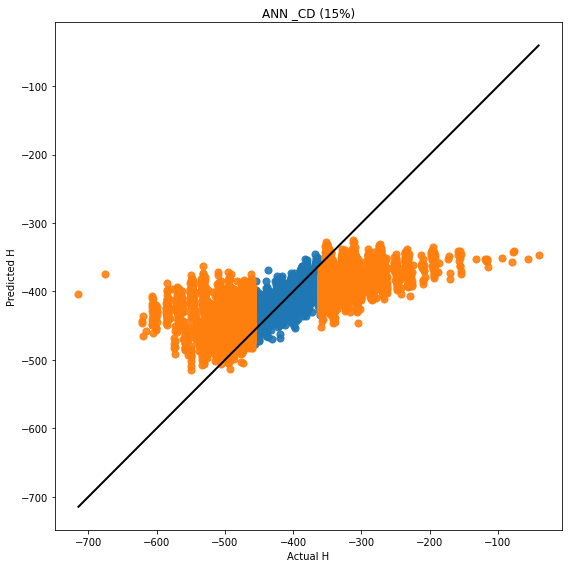

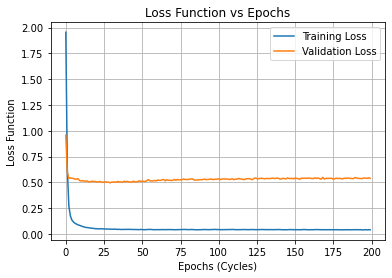

Scaled Test Loss: [4.019446849822998, 1.6523784399032593]

Training Fraction = 30%
Training Samples = 32704
Epoch 1/200
262/262 [==============================] - 1s 4ms/step - loss: 1.4178 - mae: 0.8902 - val_loss: 0.5412 - val_mae: 0.5759
Epoch 2/200
262/262 [==============================] - 1s 4ms/step - loss: 0.3764 - mae: 0.4717 - val_loss: 0.4548 - val_mae: 0.5160
Epoch 3/200
262/262 [==============================] - 1s 3ms/step - loss: 0.2416 - mae: 0.3745 - val_loss: 0.4515 - val_mae: 0.5158
Epoch 4/200
262/262 [==============================] - 1s 4ms/step - loss: 0.1814 - mae: 0.3243 - val_loss: 0.4465 - val_mae: 0.5129
Epoch 5/200
262/262 [==============================] - 1s 4ms/step - loss: 0.1471 - mae: 0.2936 - val_loss: 0.4542 - val_mae: 0.5193
Epoch 6/200
262/262 [==============================] - 1s 3ms/step - loss: 0.1303 - mae: 0.2765 - val_loss: 0.4437 - val_mae: 0.5128
Epoch 7/200
262/262 [==============================] - 1s 3ms/step - loss: 0.1185 - mae: 0.264

262/262 [==============================] - 1s 3ms/step - loss: 0.0557 - mae: 0.1409 - val_loss: 0.4487 - val_mae: 0.5043
Epoch 123/200
262/262 [==============================] - 1s 3ms/step - loss: 0.0555 - mae: 0.1407 - val_loss: 0.4478 - val_mae: 0.5013
Epoch 124/200
262/262 [==============================] - 1s 3ms/step - loss: 0.0549 - mae: 0.1397 - val_loss: 0.4447 - val_mae: 0.4997
Epoch 125/200
262/262 [==============================] - 1s 4ms/step - loss: 0.0551 - mae: 0.1391 - val_loss: 0.4420 - val_mae: 0.4992
Epoch 126/200
262/262 [==============================] - 1s 3ms/step - loss: 0.0549 - mae: 0.1395 - val_loss: 0.4455 - val_mae: 0.5021
Epoch 127/200
262/262 [==============================] - 1s 4ms/step - loss: 0.0549 - mae: 0.1397 - val_loss: 0.4457 - val_mae: 0.4996
Epoch 128/200
262/262 [==============================] - 1s 3ms/step - loss: 0.0553 - mae: 0.1405 - val_loss: 0.4452 - val_mae: 0.5016
Epoch 129/200
262/262 [==============================] - 1s 3ms/step 

Epoch 183/200
262/262 [==============================] - 1s 4ms/step - loss: 0.0526 - mae: 0.1364 - val_loss: 0.4491 - val_mae: 0.5023
Epoch 184/200
262/262 [==============================] - 1s 3ms/step - loss: 0.0529 - mae: 0.1375 - val_loss: 0.4481 - val_mae: 0.5012
Epoch 185/200
262/262 [==============================] - 1s 4ms/step - loss: 0.0513 - mae: 0.1341 - val_loss: 0.4483 - val_mae: 0.5018
Epoch 186/200
262/262 [==============================] - 1s 3ms/step - loss: 0.0516 - mae: 0.1350 - val_loss: 0.4428 - val_mae: 0.4956
Epoch 187/200
262/262 [==============================] - 1s 4ms/step - loss: 0.0520 - mae: 0.1350 - val_loss: 0.4565 - val_mae: 0.5082
Epoch 188/200
262/262 [==============================] - 1s 3ms/step - loss: 0.0519 - mae: 0.1351 - val_loss: 0.4483 - val_mae: 0.4998
Epoch 189/200
262/262 [==============================] - 1s 4ms/step - loss: 0.0522 - mae: 0.1359 - val_loss: 0.4524 - val_mae: 0.5070
Epoch 190/200
262/262 [==============================] 

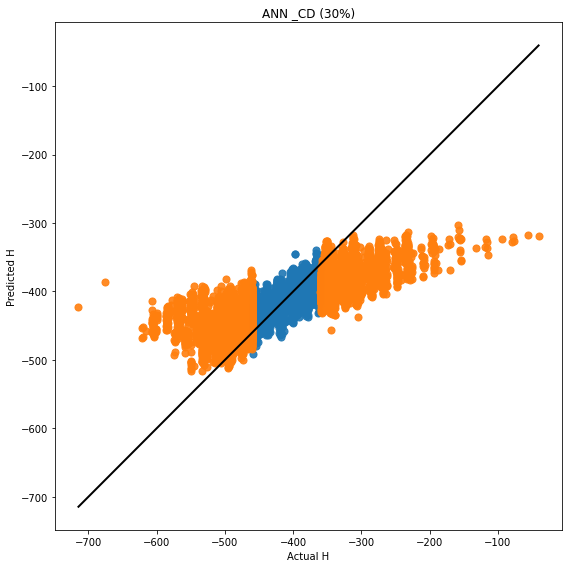

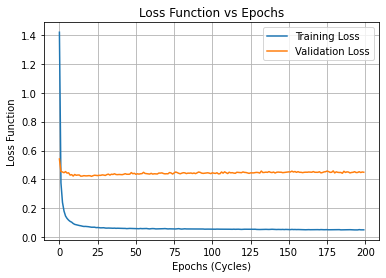

Scaled Test Loss: [3.270106315612793, 1.44932222366333]

Training Fraction = 45%
Training Samples = 49057
Epoch 1/200
393/393 [==============================] - 2s 4ms/step - loss: 1.6756 - mae: 0.9239 - val_loss: 0.5209 - val_mae: 0.5487
Epoch 2/200
393/393 [==============================] - 1s 4ms/step - loss: 0.3738 - mae: 0.4663 - val_loss: 0.4364 - val_mae: 0.5017
Epoch 3/200
393/393 [==============================] - 1s 4ms/step - loss: 0.2579 - mae: 0.3852 - val_loss: 0.4207 - val_mae: 0.4902
Epoch 4/200
393/393 [==============================] - 1s 4ms/step - loss: 0.2014 - mae: 0.3411 - val_loss: 0.4075 - val_mae: 0.4841
Epoch 5/200
393/393 [==============================] - 1s 4ms/step - loss: 0.1657 - mae: 0.3107 - val_loss: 0.4085 - val_mae: 0.4860
Epoch 6/200
393/393 [==============================] - 1s 4ms/step - loss: 0.1462 - mae: 0.2921 - val_loss: 0.4007 - val_mae: 0.4804
Epoch 7/200
393/393 [==============================] - 1s 4ms/step - loss: 0.1316 - mae: 0.2773 

393/393 [==============================] - 1s 4ms/step - loss: 0.0634 - mae: 0.1497 - val_loss: 0.3989 - val_mae: 0.4617
Epoch 123/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0633 - mae: 0.1497 - val_loss: 0.4007 - val_mae: 0.4627
Epoch 124/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0635 - mae: 0.1508 - val_loss: 0.3993 - val_mae: 0.4624
Epoch 125/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0640 - mae: 0.1511 - val_loss: 0.3960 - val_mae: 0.4571
Epoch 126/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0636 - mae: 0.1502 - val_loss: 0.3948 - val_mae: 0.4571
Epoch 127/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0635 - mae: 0.1506 - val_loss: 0.4034 - val_mae: 0.4640
Epoch 128/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0627 - mae: 0.1489 - val_loss: 0.3967 - val_mae: 0.4569
Epoch 129/200
393/393 [==============================] - 1s 4ms/step 

Epoch 183/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0614 - mae: 0.1472 - val_loss: 0.4048 - val_mae: 0.4634
Epoch 184/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0619 - mae: 0.1488 - val_loss: 0.4016 - val_mae: 0.4605
Epoch 185/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0610 - mae: 0.1467 - val_loss: 0.3995 - val_mae: 0.4582
Epoch 186/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0604 - mae: 0.1451 - val_loss: 0.3981 - val_mae: 0.4570
Epoch 187/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0609 - mae: 0.1461 - val_loss: 0.4058 - val_mae: 0.4659
Epoch 188/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0607 - mae: 0.1465 - val_loss: 0.4031 - val_mae: 0.4606
Epoch 189/200
393/393 [==============================] - 1s 4ms/step - loss: 0.0608 - mae: 0.1460 - val_loss: 0.4053 - val_mae: 0.4647
Epoch 190/200
393/393 [==============================] 

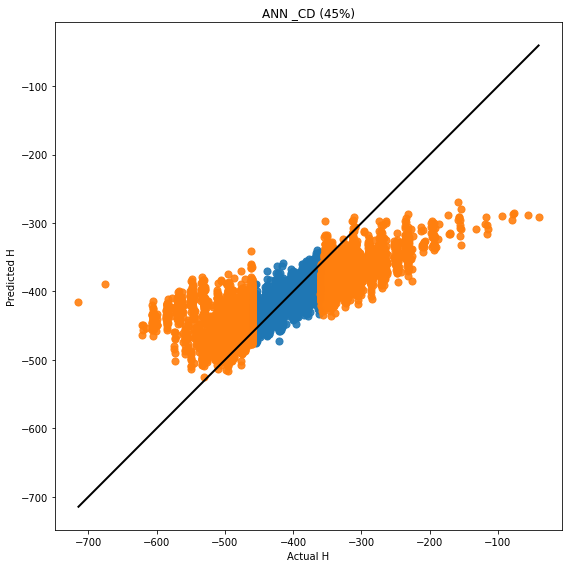

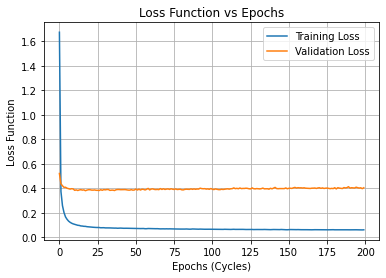

Scaled Test Loss: [2.942756175994873, 1.3508371114730835]

Training Fraction = 60%
Training Samples = 65409
Epoch 1/200
524/524 [==============================] - 2s 4ms/step - loss: 1.0367 - mae: 0.7412 - val_loss: 0.4532 - val_mae: 0.5072
Epoch 2/200
524/524 [==============================] - 2s 4ms/step - loss: 0.3412 - mae: 0.4399 - val_loss: 0.4033 - val_mae: 0.4724
Epoch 3/200
524/524 [==============================] - 2s 4ms/step - loss: 0.2571 - mae: 0.3816 - val_loss: 0.3880 - val_mae: 0.4661
Epoch 4/200
524/524 [==============================] - 2s 4ms/step - loss: 0.2065 - mae: 0.3436 - val_loss: 0.3906 - val_mae: 0.4669
Epoch 5/200
524/524 [==============================] - 2s 4ms/step - loss: 0.1760 - mae: 0.3187 - val_loss: 0.3837 - val_mae: 0.4651
Epoch 6/200
524/524 [==============================] - 2s 4ms/step - loss: 0.1575 - mae: 0.3025 - val_loss: 0.3797 - val_mae: 0.4597
Epoch 7/200
524/524 [==============================] - 2s 4ms/step - loss: 0.1421 - mae: 0.286

524/524 [==============================] - 2s 4ms/step - loss: 0.0715 - mae: 0.1602 - val_loss: 0.3945 - val_mae: 0.4542
Epoch 123/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0709 - mae: 0.1593 - val_loss: 0.3876 - val_mae: 0.4452
Epoch 124/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0714 - mae: 0.1601 - val_loss: 0.3891 - val_mae: 0.4453
Epoch 125/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0705 - mae: 0.1587 - val_loss: 0.3893 - val_mae: 0.4495
Epoch 126/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0712 - mae: 0.1597 - val_loss: 0.3889 - val_mae: 0.4469
Epoch 127/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0714 - mae: 0.1600 - val_loss: 0.3918 - val_mae: 0.4503
Epoch 128/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0709 - mae: 0.1587 - val_loss: 0.3884 - val_mae: 0.4447
Epoch 129/200
524/524 [==============================] - 2s 4ms/step 

Epoch 183/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0687 - mae: 0.1556 - val_loss: 0.3891 - val_mae: 0.4477
Epoch 184/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0688 - mae: 0.1556 - val_loss: 0.3889 - val_mae: 0.4480
Epoch 185/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0695 - mae: 0.1567 - val_loss: 0.3887 - val_mae: 0.4477
Epoch 186/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0683 - mae: 0.1546 - val_loss: 0.3899 - val_mae: 0.4456
Epoch 187/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0693 - mae: 0.1562 - val_loss: 0.3910 - val_mae: 0.4478
Epoch 188/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0687 - mae: 0.1558 - val_loss: 0.3956 - val_mae: 0.4547
Epoch 189/200
524/524 [==============================] - 2s 4ms/step - loss: 0.0685 - mae: 0.1550 - val_loss: 0.3934 - val_mae: 0.4489
Epoch 190/200
524/524 [==============================] 

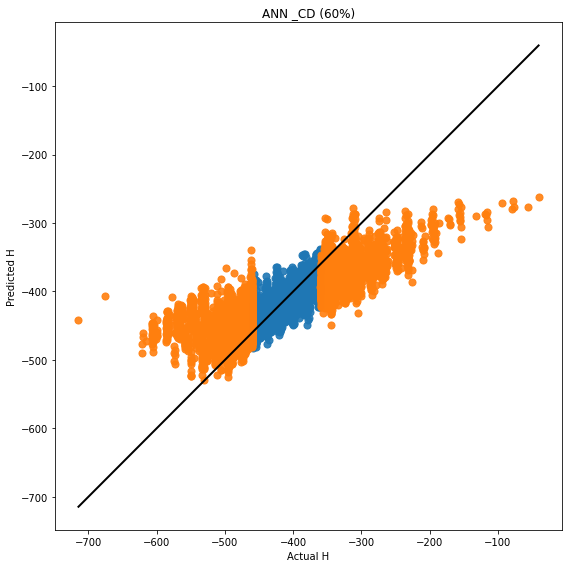

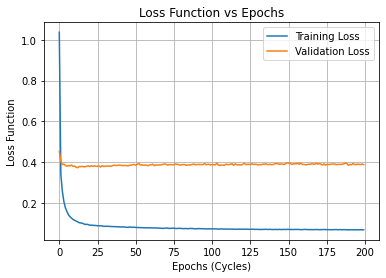

Scaled Test Loss: [2.640423059463501, 1.2658213376998901]

Training Fraction = 75%
Training Samples = 81762
Epoch 1/200
655/655 [==============================] - 3s 4ms/step - loss: 1.4271 - mae: 0.8177 - val_loss: 0.4404 - val_mae: 0.4992
Epoch 2/200
655/655 [==============================] - 2s 4ms/step - loss: 0.3357 - mae: 0.4356 - val_loss: 0.3856 - val_mae: 0.4614
Epoch 3/200
655/655 [==============================] - 2s 4ms/step - loss: 0.2558 - mae: 0.3799 - val_loss: 0.3702 - val_mae: 0.4505
Epoch 4/200
655/655 [==============================] - 2s 4ms/step - loss: 0.2106 - mae: 0.3455 - val_loss: 0.3701 - val_mae: 0.4499
Epoch 5/200
655/655 [==============================] - 2s 4ms/step - loss: 0.1853 - mae: 0.3259 - val_loss: 0.3684 - val_mae: 0.4540
Epoch 6/200
655/655 [==============================] - 2s 4ms/step - loss: 0.1652 - mae: 0.3083 - val_loss: 0.3634 - val_mae: 0.4470
Epoch 7/200
655/655 [==============================] - 2s 4ms/step - loss: 0.1537 - mae: 0.296

655/655 [==============================] - 2s 4ms/step - loss: 0.0770 - mae: 0.1658 - val_loss: 0.3707 - val_mae: 0.4292
Epoch 123/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0775 - mae: 0.1661 - val_loss: 0.3689 - val_mae: 0.4289
Epoch 124/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0777 - mae: 0.1668 - val_loss: 0.3727 - val_mae: 0.4327
Epoch 125/200
655/655 [==============================] - 2s 3ms/step - loss: 0.0766 - mae: 0.1652 - val_loss: 0.3717 - val_mae: 0.4289
Epoch 126/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0771 - mae: 0.1661 - val_loss: 0.3686 - val_mae: 0.4243
Epoch 127/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0774 - mae: 0.1662 - val_loss: 0.3791 - val_mae: 0.4385
Epoch 128/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0769 - mae: 0.1652 - val_loss: 0.3711 - val_mae: 0.4300
Epoch 129/200
655/655 [==============================] - 2s 4ms/step 

Epoch 183/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0742 - mae: 0.1612 - val_loss: 0.3738 - val_mae: 0.4317
Epoch 184/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0746 - mae: 0.1618 - val_loss: 0.3724 - val_mae: 0.4296
Epoch 185/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0750 - mae: 0.1623 - val_loss: 0.3724 - val_mae: 0.4303
Epoch 186/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0744 - mae: 0.1612 - val_loss: 0.3691 - val_mae: 0.4282
Epoch 187/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0750 - mae: 0.1624 - val_loss: 0.3754 - val_mae: 0.4317
Epoch 188/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0753 - mae: 0.1632 - val_loss: 0.3693 - val_mae: 0.4268
Epoch 189/200
655/655 [==============================] - 2s 4ms/step - loss: 0.0752 - mae: 0.1621 - val_loss: 0.3700 - val_mae: 0.4280
Epoch 190/200
655/655 [==============================] 

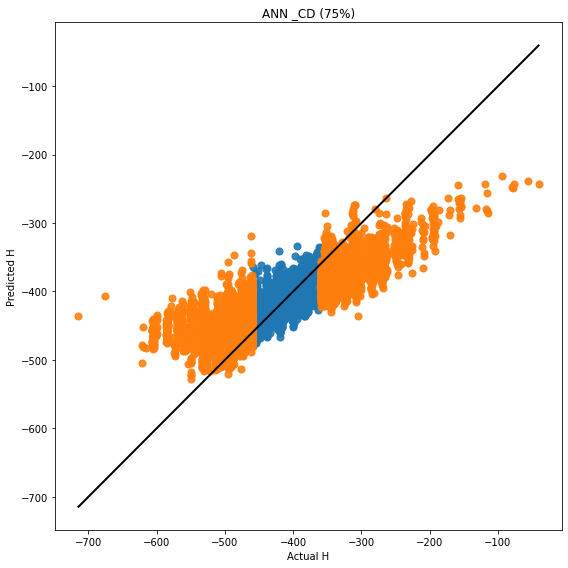

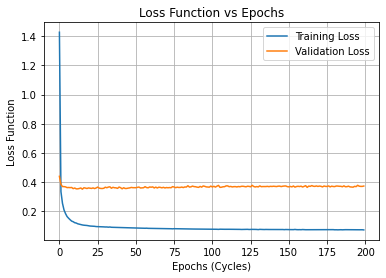

Scaled Test Loss: [2.5175912380218506, 1.2419185638427734]

Training Fraction = 90%
Training Samples = 98114
Epoch 1/200
785/785 [==============================] - 21s 17ms/step - loss: 0.7981 - mae: 0.6510 - val_loss: 0.4145 - val_mae: 0.4792
Epoch 2/200
785/785 [==============================] - 7s 9ms/step - loss: 0.3268 - mae: 0.4262 - val_loss: 0.3778 - val_mae: 0.4536
Epoch 3/200
785/785 [==============================] - 7s 9ms/step - loss: 0.2638 - mae: 0.3834 - val_loss: 0.3644 - val_mae: 0.4485
Epoch 4/200
785/785 [==============================] - 6s 7ms/step - loss: 0.2237 - mae: 0.3554 - val_loss: 0.3573 - val_mae: 0.4485
Epoch 5/200
785/785 [==============================] - 3s 4ms/step - loss: 0.1958 - mae: 0.3329 - val_loss: 0.3605 - val_mae: 0.4527
Epoch 6/200
785/785 [==============================] - 3s 4ms/step - loss: 0.1764 - mae: 0.3157 - val_loss: 0.3562 - val_mae: 0.4439
Epoch 7/200
785/785 [==============================] - 3s 4ms/step - loss: 0.1616 - mae: 0.

785/785 [==============================] - 3s 4ms/step - loss: 0.0829 - mae: 0.1724 - val_loss: 0.3627 - val_mae: 0.4258
Epoch 123/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0828 - mae: 0.1719 - val_loss: 0.3624 - val_mae: 0.4274
Epoch 124/200
785/785 [==============================] - 3s 3ms/step - loss: 0.0832 - mae: 0.1723 - val_loss: 0.3605 - val_mae: 0.4259
Epoch 125/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0832 - mae: 0.1728 - val_loss: 0.3610 - val_mae: 0.4263
Epoch 126/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0821 - mae: 0.1705 - val_loss: 0.3611 - val_mae: 0.4256
Epoch 127/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0827 - mae: 0.1716 - val_loss: 0.3610 - val_mae: 0.4255
Epoch 128/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0830 - mae: 0.1721 - val_loss: 0.3600 - val_mae: 0.4249
Epoch 129/200
785/785 [==============================] - 3s 4ms/step 

Epoch 183/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0812 - mae: 0.1688 - val_loss: 0.3619 - val_mae: 0.4252
Epoch 184/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0809 - mae: 0.1686 - val_loss: 0.3602 - val_mae: 0.4217
Epoch 185/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0801 - mae: 0.1672 - val_loss: 0.3582 - val_mae: 0.4215
Epoch 186/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0802 - mae: 0.1680 - val_loss: 0.3604 - val_mae: 0.4230
Epoch 187/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0813 - mae: 0.1695 - val_loss: 0.3543 - val_mae: 0.4173
Epoch 188/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0814 - mae: 0.1695 - val_loss: 0.3522 - val_mae: 0.4162
Epoch 189/200
785/785 [==============================] - 3s 4ms/step - loss: 0.0804 - mae: 0.1673 - val_loss: 0.3561 - val_mae: 0.4182
Epoch 190/200
785/785 [==============================] 

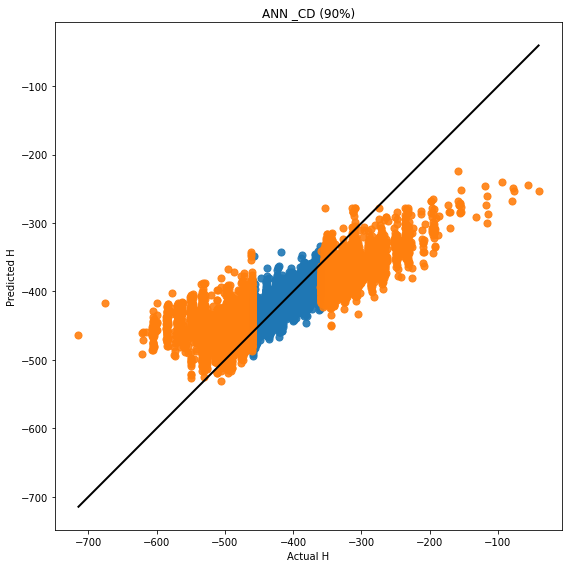

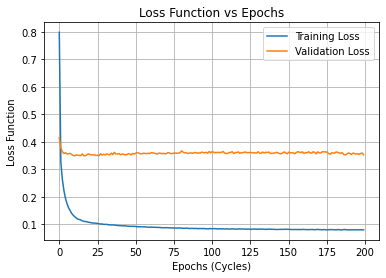

Scaled Test Loss: [2.4882030487060547, 1.2069121599197388]


In [3]:
#ANN 
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")
H = data["H"]
smiles = data["SMILES"].values
y = data["H"].values

print("Started")
# ===============================
# MORGAN FINGERPRINT OF SMILES
# ===============================

def smiles_to_fingerprint(smiles_string):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return np.zeros((4096,), dtype=int)
    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=4096)
    return np.array(fp, dtype=int)

#Fingerprint Conversion
X = np.array([smiles_to_fingerprint(sm) for sm in smiles])
y = H.values

print(X.shape)
print(X.dtype)
print("success")

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test_all = X[test_mask]
y_test_all = y[test_mask]
# ===============================
# ===============================
# FIX TEST SET TO 24,869 SAMPLES
# ===============================

np.random.seed(42)

test_indices = np.random.choice(
    len(X_test_all),
    size=24869,
    replace=False
)      
X_test = X_test_all[test_indices]
y_test = y_test_all[test_indices]

print("Fixed Test Samples:", len(X_test))
# ===============================

fractions = [0.15, 0.30, 0.45, 0.60, 0.75, 0.90]

for frac in fractions:

    train_size = int(frac * len(X_train_full))
    np.random.default_rng(42)
    idx = np.random.choice(
        len(X_train_full),
        train_size,
        replace=False
            )

    X_train_sub = X_train_full[idx]
    y_train_sub = y_train_full[idx]

    print(f"\nTraining Fraction = {frac*100:.0f}%")
    print("Training Samples =", len(X_train_sub))

    # -----------------------------
    # Scale X and y
    # -----------------------------
    x_scaler = StandardScaler() 
    y_scaler = StandardScaler() 

    X_train_scaled = x_scaler.fit_transform(X_train_sub) 
    X_test_scaled = x_scaler.transform(X_test)

    y_train_scaled = y_scaler.fit_transform(y_train_sub.reshape(-1,1)).flatten()
    y_test_scaled  = y_scaler.transform(y_test.reshape(-1,1)).flatten()

    # Construction of model
    # Build the DNN model
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4096,)),  # Input layer matching fingerprint size
        tf.keras.layers.Dense(128, activation='relu',  kernel_regularizer=l2(1e-5) ,kernel_initializer='he_normal'),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1)  # Output layer for regression
    ])
    #%%
    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

    # Train the model
    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        validation_split=0.2,
        epochs=200,
        batch_size=100,
        verbose=1
    )
    print(history.history.keys())
    
    # Make predictions
    # Predict (scaled output)
    y_pred_train_scaled = model.predict(X_train_scaled)
    y_pred_test_scaled  = model.predict(X_test_scaled)

    # Inverse transform predictions
    y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled).flatten()
    y_pred_test  = y_scaler.inverse_transform(y_pred_test_scaled).flatten()

    # Metrics on ORIGINAL y
    mse_train = mean_squared_error(y_train_sub, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_sub, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_pred_test)

    print("\nResults")
    print("-"*40)
    print(f"Train MSE : {mse_train:.4f}")
    print(f"Train R²  : {r2_train:.4f}")
    print(f"Train RMSE : {rmse_train:.4f}")
    print(f"Test MSE  : {mse_test:.4f}")
    print(f"Test R²   : {r2_test:.4f}")
    print(f"Test RMSE  : {rmse_test:.4f}")

    #%%
    # Total data points
    total_data_points = len(smiles)
    data_points_used_for_training = len(X_train_sub)
    data_points_used_for_testing = len(X_test)

    #%% Print the total and split data points
    print(f'Total Data Points: {total_data_points}')
    print(f'Number of Data Points Used for Training: {data_points_used_for_training}')
    print(f'Number of Data Points Used for Testing: {data_points_used_for_testing}')

    # ===============================
    # TRAIN PARITY PLOT
    # ===============================

    plt.figure(figsize=(8,8))

    plt.scatter(
        y_train_sub,
        y_pred_train,
        s=50,
        alpha=0.9
    )

    # ===============================
    # TEST PARITY PLOT
    # ===============================
    plt.scatter(
        y_test,
        y_pred_test,
        s=50,
        alpha=0.9
    )

    min_val = min(y_train_sub.min(), y_pred_train.min(),y_test.min(), y_pred_test.min())
    max_val = max(y_train_sub.max(), y_pred_train.max(),y_test.max(), y_pred_test.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'k-',
        linewidth=2
    )

    plt.xlabel('Actual H')
    plt.ylabel('Predicted H')
    plt.title(f'ANN _CD ({int(frac*100)}%)')
    plt.savefig(f"CD_ANN_Parity_{int(frac*100)}.png",
            dpi=600,
            bbox_inches='tight')
    plt.tight_layout()
    plt.show()

    #%%
    # Plot training & validation loss values
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.xlabel('Epochs (Cycles)')
    plt.ylabel('Loss Function')
    plt.title('Loss Function vs Epochs')
    plt.legend()
    plt.savefig(f"lossvsepoch_ANN_{int(frac*100)}.png",dpi=300)
    plt.grid(True)
    plt.show()

    # Final train & validation loss
    final_train_loss = history.history['loss'][-1]
    final_val_loss   = history.history['val_loss'][-1]

    # Evaluate test set (returns only loss)
    test_loss = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
    print("Scaled Test Loss:", test_loss)


Started
(133885, 4096)
Training samples : 109016
Testing samples  : 24869
Training : 87212
Validation : 21804
Testing : 24869
Epoch 1/200
873/873 [==============================] - 29s 33ms/step - loss: 0.6137 - mae: 0.5704 - val_loss: 0.3885 - val_mae: 0.4697
Epoch 2/200
873/873 [==============================] - 28s 32ms/step - loss: 0.2827 - mae: 0.3957 - val_loss: 0.3542 - val_mae: 0.4474
Epoch 3/200
873/873 [==============================] - 28s 33ms/step - loss: 0.1918 - mae: 0.3265 - val_loss: 0.3544 - val_mae: 0.4478
Epoch 4/200
873/873 [==============================] - 28s 32ms/step - loss: 0.1387 - mae: 0.2802 - val_loss: 0.3355 - val_mae: 0.4236
Epoch 5/200
873/873 [==============================] - 27s 31ms/step - loss: 0.1116 - mae: 0.2507 - val_loss: 0.3340 - val_mae: 0.4272
Epoch 6/200
873/873 [==============================] - 28s 32ms/step - loss: 0.0962 - mae: 0.2321 - val_loss: 0.3195 - val_mae: 0.3996
Epoch 7/200
873/873 [==============================] - 28s 33ms/

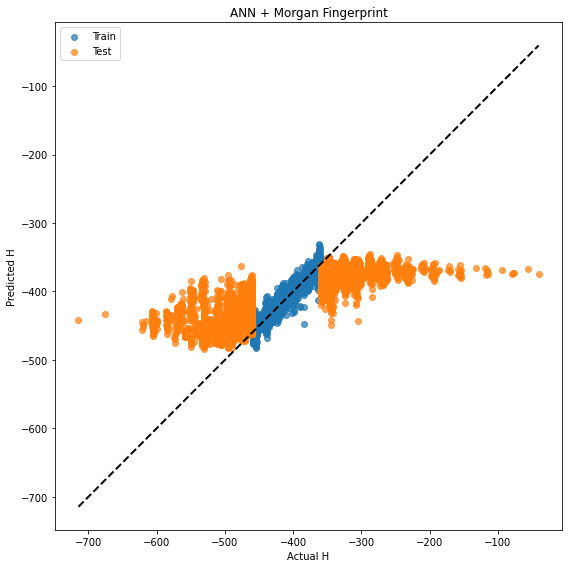

In [1]:
##########################################################
# MORGAN FINGERPRINT + ANN REGRESSION FOR WHOLE DATASET
##########################################################

# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.regularizers import l2

from rdkit import Chem
from rdkit.Chem import AllChem

import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
y = data["H"].values

print("Started")

# ===============================
# MORGAN FINGERPRINT
# ===============================

def smiles_to_fingerprint(smiles_string):

    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return np.zeros((4096,), dtype=np.uint8)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=3,
        nBits=4096
    )

    return np.array(fp, dtype=np.uint8)


X = np.array([smiles_to_fingerprint(sm) for sm in smiles],
             dtype=np.float32)

print(X.shape)

# ===============================
# EXTRAPOLATION SPLIT
# ===============================

train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

X_train_full = X[train_mask]
y_train_full = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("Training samples :", len(X_train_full))
print("Testing samples  :", len(X_test))

# ===============================
# VALIDATION SPLIT
# ===============================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42
)

print("Training :", len(X_train))
print("Validation :", len(X_val))
print("Testing :", len(X_test))

# ===============================
# SCALE DATA
# ===============================

x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val = x_scaler.transform(X_val)
X_test = x_scaler.transform(X_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1,1)
).ravel()

y_val_scaled = y_scaler.transform(
    y_val.reshape(-1,1)
).ravel()

# ===============================
# BUILD MODEL
# ===============================

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(4096,)),

    # Hidden Layer 1
    tf.keras.layers.Dense(512,activation="relu"),
    tf.keras.layers.Dropout(0.10),

    # Hidden Layer 2
    tf.keras.layers.Dense(1024,activation="relu"),
    tf.keras.layers.Dropout(0.10),

    # Hidden Layer 3
    tf.keras.layers.Dense(2048,activation="relu"),
    tf.keras.layers.Dropout(0.10),

    # Output Layer
    tf.keras.layers.Dense(1)

])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

# ===============================
# TRAIN MODEL
# ===============================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_scaled,
    validation_data=(X_val, y_val_scaled),
    epochs=200,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

# ===============================
# PREDICTIONS
# ===============================

y_pred_train = y_scaler.inverse_transform(
    model.predict(X_train)
).ravel()

y_pred_val = y_scaler.inverse_transform(
    model.predict(X_val)
).ravel()

y_pred_test = y_scaler.inverse_transform(
    model.predict(X_test)
).ravel()

# ===============================
# METRICS
# ===============================

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

mse_val = mean_squared_error(y_val, y_pred_val)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_pred_val)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nResults")
print("-"*40)

print(f"Train R² : {r2_train:.4f}")
print(f"Train RMSE : {rmse_train:.4f}")

print(f"Validation R² : {r2_val:.4f}")
print(f"Validation RMSE : {rmse_val:.4f}")

print(f"Test R² : {r2_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}")

# ===============================
# PARITY PLOT
# ===============================

plt.figure(figsize=(8,8))

plt.scatter(
    y_train,
    y_pred_train,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_pred_test,
    label="Test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_pred_train.min(),
    y_pred_test.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_pred_train.max(),
    y_pred_test.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    linewidth=2
)

plt.xlabel("Actual H")
plt.ylabel("Predicted H")
plt.title("ANN + Morgan Fingerprint")
plt.legend()

plt.tight_layout()

plt.savefig(
    "ANN_MFP_Parity.png",
    dpi=600
)

plt.show()

In [4]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import AllChem
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
# ===============================
# LOAD DATA
# ===============================
data = pd.read_csv("qm133885_properties.csv")

smiles = data["SMILES"].values
y = data["H"].values
print("STARTED")
# ===============================
# SPLIT DATA
# ===============================
train_mask = (y >= -460) & (y <= -360)
test_mask = ~train_mask

smiles_train_full = smiles[train_mask]
smiles_test = smiles[test_mask]

y_train_full = y[train_mask]
y_test = y[test_mask]

smiles_train, smiles_val, y_train, y_val = train_test_split(
    smiles_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

# ===============================
# FINGERPRINT FUNCTION
# ===============================
def smiles_to_fp(smiles_string, radius, nBits):
    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return np.zeros((nBits,), dtype=np.uint8)

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=nBits
    )

    return np.array(fp, dtype=np.uint8)

# ===============================
# MODEL
# ===============================
def create_model(input_dim, hidden_layers, lr=0.001):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for neurons in hidden_layers:
        model.add(tf.keras.layers.Dense(neurons, activation="relu"))

    model.add(tf.keras.layers.Dense(1))

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )
    return model

# ===============================
# PARAMETER GRID
# ===============================
radius_list = [2, 3]
nBits_list = [1024, 2048, 4096]

architecture_list = [
    (32,),
    (64,),
    (128,),
    (256,),
    (512,),
    (1024,),
    (2048,),
    (32,64),
    (64,128),
    (128,256),
    (256,512),
    (512,1024),
    (1024,2048),
    (32,64,128),
    (64,128,256),
    (128,256,512),
    (256,512,1024),
    (512,1024,2048)
]

lr_list = [0.001]
total_runs = (
    len(radius_list)
    * len(nBits_list)
    * len(lr_list)
    * len(architecture_list)
)

results = []
best_val_r2 = -np.inf
best_result = None

# ===============================
# TUNING LOOP
# ===============================
run = 1

for radius in radius_list:
    for nBits in nBits_list:

        print(f"\nFingerprint: radius={radius}, nBits={nBits}")

        # -----------------------
        # BUILD FINGERPRINTS
        # -----------------------
        X_train = np.array([smiles_to_fp(sm, radius, nBits) for sm in smiles_train], dtype=np.float32)
        X_val   = np.array([smiles_to_fp(sm, radius, nBits) for sm in smiles_val], dtype=np.float32)
        X_test  = np.array([smiles_to_fp(sm, radius, nBits) for sm in smiles_test], dtype=np.float32)

        # IMPORTANT: scale X ONLY (safe but optional for fingerprints)
        x_scaler = StandardScaler()
        X_train = x_scaler.fit_transform(X_train)
        X_val   = x_scaler.transform(X_val)
        X_test  = x_scaler.transform(X_test)
        # scale y
        y_scaler = StandardScaler()
        y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
        y_val_scaled   = y_scaler.transform(y_val.reshape(-1,1)).ravel()

        for arch in architecture_list:
            for lr in lr_list:
                print(
                    f"\n[{run}/{total_runs}] "
                    f"radius={radius}, "
                    f"nBits={nBits}, "
                    f"architecture={arch}, "
                    f"lr={lr}"
                )
                tf.keras.backend.clear_session()  # IMPORTANT FIX
                
                model = create_model(nBits, arch, lr)

                early_stop = tf.keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=15,
                    restore_best_weights=True
                )

                model.fit(
                    X_train,
                    y_train_scaled,
                    validation_data=(X_val, y_val_scaled),
                    epochs=100,
                    batch_size=100,
                    callbacks=[early_stop],
                    verbose=0
                )

                # predictions
                y_train_pred = y_scaler.inverse_transform(model.predict(X_train, verbose=0)).ravel()
                y_val_pred   = y_scaler.inverse_transform(model.predict(X_val, verbose=0)).ravel()
                y_test_pred  = y_scaler.inverse_transform(model.predict(X_test, verbose=0)).ravel()

                # scores
                r2_train = r2_score(y_train, y_train_pred)
                r2_val   = r2_score(y_val, y_val_pred)
                r2_test  = r2_score(y_test, y_test_pred)

                print(f"R² train={r2_train:.3f} val={r2_val:.3f} test={r2_test:.3f}")

                results.append({
                    "radius": radius,
                    "nBits": nBits,
                    "arch": str(arch),
                    "lr": lr,
                    "r2_train": r2_train,
                    "r2_val": r2_val,
                    "r2_test": r2_test
                })

                if r2_val > best_val_r2:
                    best_val_r2 = r2_val
                    best_result = results[-1]

                run += 1

# ===============================
# RESULTS
# ===============================
df = pd.DataFrame(results).sort_values("r2_val", ascending=False)

print(df.head(10))

print("\nBEST:")
print(best_result)

STARTED

Fingerprint: radius=2, nBits=1024

[1/108] radius=2, nBits=1024, architecture=(32,), lr=0.001
R² train=0.807 val=0.638 test=0.619

[2/108] radius=2, nBits=1024, architecture=(64,), lr=0.001
R² train=0.815 val=0.635 test=0.628

[3/108] radius=2, nBits=1024, architecture=(128,), lr=0.001
R² train=0.830 val=0.635 test=0.639

[4/108] radius=2, nBits=1024, architecture=(256,), lr=0.001
R² train=0.902 val=0.632 test=0.672

[5/108] radius=2, nBits=1024, architecture=(512,), lr=0.001
R² train=0.982 val=0.678 test=0.696

[6/108] radius=2, nBits=1024, architecture=(1024,), lr=0.001
R² train=0.967 val=0.679 test=0.696

[7/108] radius=2, nBits=1024, architecture=(2048,), lr=0.001
R² train=0.950 val=0.675 test=0.703

[8/108] radius=2, nBits=1024, architecture=(32, 64), lr=0.001
R² train=0.783 val=0.626 test=0.600

[9/108] radius=2, nBits=1024, architecture=(64, 128), lr=0.001
R² train=0.821 val=0.616 test=0.608

[10/108] radius=2, nBits=1024, architecture=(128, 256), lr=0.001
R² train=0.98

R² train=0.813 val=0.625 test=0.618

[81/108] radius=3, nBits=2048, architecture=(64, 128), lr=0.001
R² train=0.862 val=0.623 test=0.632

[82/108] radius=3, nBits=2048, architecture=(128, 256), lr=0.001
R² train=0.992 val=0.696 test=0.652

[83/108] radius=3, nBits=2048, architecture=(256, 512), lr=0.001
R² train=0.992 val=0.735 test=0.646

[84/108] radius=3, nBits=2048, architecture=(512, 1024), lr=0.001
R² train=0.992 val=0.745 test=0.666

[85/108] radius=3, nBits=2048, architecture=(1024, 2048), lr=0.001
R² train=0.996 val=0.772 test=0.650

[86/108] radius=3, nBits=2048, architecture=(32, 64, 128), lr=0.001
R² train=0.801 val=0.629 test=0.580

[87/108] radius=3, nBits=2048, architecture=(64, 128, 256), lr=0.001
R² train=0.987 val=0.662 test=0.648

[88/108] radius=3, nBits=2048, architecture=(128, 256, 512), lr=0.001
R² train=0.991 val=0.715 test=0.613

[89/108] radius=3, nBits=2048, architecture=(256, 512, 1024), lr=0.001
R² train=0.997 val=0.752 test=0.631

[90/108] radius=3, nBits=